# Speciated PM2.5 MAIA Surface Monitor Tutorial
The following tutorial guides users to explore the percent contribution of five reported species that make up PM2.5 measurements from MAIA Surface Monitor Collections. Users are guided to login via earthaccess to NASA's Earthdat Search portal for data downlod, guided to input a time frame of interest, and then to select a Primary Target Area (PTA) of interest, based on the  number of granules availble during that time frame. Percent contribution bar charts are created for each date there is data.

Mission Point of Contact/Tutorial Author
- Sarah Scott: sarah.r.scott@nasa.gov

ASDC Project Scientist
- Hazem Mahmoud: hazem.mahmoud@nasa.gov

## Installations and Imports

In [1]:
!pip install earthaccess netCDF4


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\srscott4\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import getpass
import earthaccess
import datetime as dt
import folium
import os
import pandas as pd
import re
import numpy as np
import pandas as pd
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import time
from datetime import datetime
import matplotlib.dates as mdates
import glob
import platform
from collections import Counter

In [3]:
# Establishing access to EarthData
#User needs to create an account at https://www.earthdata.nasa.gov/
#Function earthaccess.login prompts for EarthData login and password.
auth = earthaccess.login(strategy="interactive", persist=True)

In [4]:
#timeframe of interest
print('enter period of interest, start and end dates, in the form YYYYMMDD')
datestamp_ini = input('enter start date of interest ')
datestamp_fin = input('enter end date of interest ')
start_date = int(datestamp_ini)
end_date = int(datestamp_fin)
yyyy_ini = start_date//10000
mm_ini = (start_date//100 - yyyy_ini*100)
dd_ini = (start_date - yyyy_ini*10000 - mm_ini*100)
yyyy_fin = end_date//10000
mm_fin = (end_date//100 - yyyy_fin*100)
dd_fin = (end_date - yyyy_fin*10000 - mm_fin*100)
print(yyyy_ini, mm_ini, dd_ini, yyyy_fin, mm_fin, dd_fin)
date_start = str('%4.4i-%2.2i-%2.2i 00:00:00' %(yyyy_ini, mm_ini, dd_ini))
date_end = str('%4.4i-%2.2i-%2.2i 23:59:59' %(yyyy_fin, mm_fin, dd_fin))

enter period of interest, start and end dates, in the form YYYYMMDD
2025 9 1 2025 9 12


In [5]:
concept_id = "C3880763231-LARC_CLOUD"
granules = earthaccess.search_data(concept_id=concept_id,temporal=(f"{yyyy_ini}-{mm_ini}-{dd_ini}", f"{yyyy_fin}-{mm_fin}-{dd_fin}"),)
print(f"Found {len(granules)} total granules across all regions.\n")
granule_ids = [g["umm"]["RelatedUrls"][0]["URL"] for g in granules]

all_cities = []
for g in granule_ids:
  parts = g.split("/")[-1].split("_")
  if len(parts) > 6:
    all_cities.append(parts[6])

counts = Counter(all_cities)

maia_ptas = ["CHL-Santiago", "ESP-Barcelona", "ETH-AddisAbaba", "IND-Delhi", "ISR-TelAviv", "ITA-Rome", "KOR-Seoul",
             "TWN-Taipei", "USA-Atlanta", "USA-Boston", "USA-LosAngeles", "ZAF-Johannesburg"]

print(f" Available Granules ({yyyy_ini}-{mm_ini}-{dd_ini} to {yyyy_fin}-{mm_fin}-{dd_fin})")
for number, pta in enumerate(maia_ptas, start=1):
  available_count = counts.get(pta, 0)
  print(f"{number}. {pta:<20} ({available_count} files available)")

selection = int(input("\nEnter PTA number: "))
site = maia_ptas[selection - 1]

site_ids = [
    g
    for g in granule_ids
    if len(g.split("/")[-1].split("_")) > 6 and g.split("/")[-1].split("_")[6] == site
]

Found 60 total granules across all regions.

 Available Granules (2025-9-1 to 2025-9-12)
1. CHL-Santiago         (0 files available)
2. ESP-Barcelona        (13 files available)
3. ETH-AddisAbaba       (0 files available)
4. IND-Delhi            (13 files available)
5. ISR-TelAviv          (0 files available)
6. ITA-Rome             (13 files available)
7. KOR-Seoul            (0 files available)
8. TWN-Taipei           (0 files available)
9. USA-Atlanta          (4 files available)
10. USA-Boston           (4 files available)
11. USA-LosAngeles       (13 files available)
12. ZAF-Johannesburg     (0 files available)


## Speciated analysis

In [6]:
dir = 'MAIA_SURFACEMONITOR_PM_2.5_SPECIES'
os.makedirs(dir, exist_ok=True)

download_directory = os.path.join(dir, site)
if os.path.exists(download_directory):
    print(download_directory)

# # else:
download_files = earthaccess.download(site_ids,local_path=download_directory)

MAIA_SURFACEMONITOR_PM_2.5_SPECIES\ITA-Rome


QUEUEING TASKS | :   0%|          | 0/13 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/13 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/13 [00:00<?, ?it/s]

In [15]:
def nc_to_tidy_dataframe(file_path):
    nc = Dataset(file_path, 'r')
    pm25 = nc.groups["PM_2.5"]
    records = []

    for species_name, species_group in pm25.groups.items():
        conc_var = species_group.variables.get('pm_mass_concentration')
        conc_vals = conc_var[:]

        if hasattr(conc_var, '_FillValue'):
            conc_vals = np.ma.masked_equal(conc_vals, conc_var._FillValue)

        conc_vals = np.ma.filled(conc_vals, np.nan)
        conc_vals = np.where(conc_vals < -900, np.nan, conc_vals)

        mon_info = species_group.groups.get('Monitor_Information')
        lats = mon_info.variables['latitude'][:] if 'latitude' in mon_info.variables else [np.nan] * len(conc_vals)
        lons = mon_info.variables['longitude'][:] if 'longitude' in mon_info.variables else [np.nan] * len(conc_vals)

        site_names = []
        if 'site_name' in mon_info.variables:
            raw_sites = mon_info.variables['site_name'][:]
            site_names = [s.decode('utf-8', errors='ignore').strip() if isinstance(s, (bytes, np.bytes_)) else str(s).strip() for s in raw_sites]
        else:
            site_names = [None] * len(conc_vals)

        date_key = next((k for k in species_group.variables.keys() if 'date' in k or 'time' in k), None)
        dates = species_group.variables[date_key][:] if date_key else [np.nan] * len(conc_vals)
        dates = [d.decode('utf-8', errors='ignore').strip() if isinstance(d, (bytes, np.bytes_)) else str(d) for d in dates]

        for i in range(len(conc_vals)):
            lat_val = lats[i] if -90 <= lats[i] <= 90 else np.nan
            lon_val = lons[i] if -180 <= lons[i] <= 180 else np.nan
            records.append({'date': dates[i],'site_name': site_names[i],'latitude': lat_val,'longitude': lon_val,'species': species_name,'pm_mass_concentration': conc_vals[i]})

    nc.close()
    df = pd.DataFrame(records)
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['pm_mass_concentration']).reset_index(drop=True)
    return df
file_paths = glob.glob(f'{dir}/{site}/*.nc') #for speciated pm only
dfs = []
for f in file_paths:
    single_df = nc_to_tidy_dataframe(f)
    single_df['file_source'] = f
    dfs.append(single_df)

master_df = pd.concat(dfs, ignore_index=True)
master_df = master_df.sort_values(by="date")

species         Dust  Elemental_Carbon  Nitrate  Organic_Carbon  Sulfate
date_str                                                                
2025-08-31  0.054200          0.000000   0.2600        0.000000   0.5200
2025-09-01  0.173300          0.287500   0.3625        1.618000   0.7600
2025-09-02  0.060300          0.260000   0.3600        1.750000   0.8100
2025-09-03  0.037000          0.282500   0.3525        1.790000   0.8575
2025-09-04  0.090800          0.460000   0.4900        2.720000   1.2100
2025-09-05  0.196720          0.575000   0.4800        2.303333   1.2620
2025-09-06  0.099700          0.360000   0.3700        2.630000   0.6900
2025-09-07  0.158775          0.230000   0.3550        2.312000   1.0200
2025-09-08  0.111300          0.400000   0.5100        3.470000   1.3500
2025-09-09  0.028100          0.340000   2.3150        2.910000   2.0425
2025-09-10  1.217200          0.603333   0.7950        1.530000   1.0450
2025-09-11  0.016350          0.242500   0.3025    

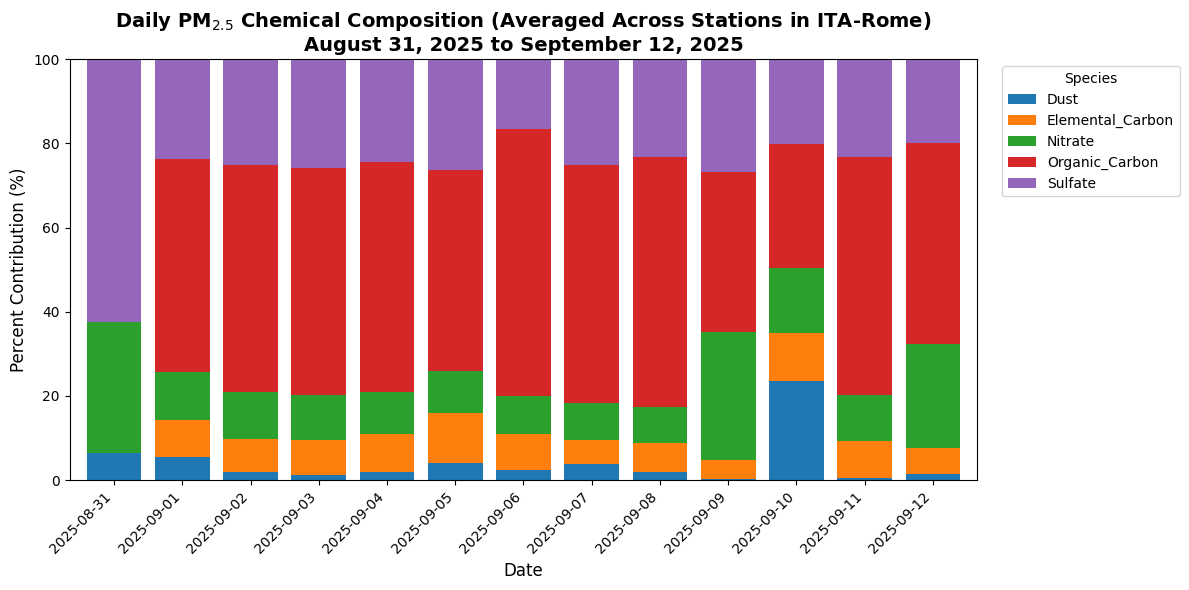

In [ ]:
daily_avg = (master_df.groupby(['date', 'species'])['pm_mass_concentration'].mean().reset_index())
daily_avg['date_str'] = daily_avg['date'].dt.strftime('%Y-%m-%d')
daily_avg = daily_avg.sort_values(by="date")
pivot_df = daily_avg.pivot(index='date_str', columns='species', values='pm_mass_concentration').fillna(0)
pivot_df = pivot_df[pivot_df.sum(axis=1) > 0]
pivot_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

unique_species = pivot_pct.columns
colors = plt.cm.tab10.colors[: len(unique_species)]

fig, ax = plt.subplots(figsize=(12, 6))
pivot_pct.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.8)
start_date = pivot_pct.index[0]
end_date = pivot_pct.index[-1]

title_start_date = datetime.strptime(start_date, "%Y-%m-%d").strftime("%B %d, %Y")
title_end_date = datetime.strptime(end_date, "%Y-%m-%d").strftime("%B %d, %Y")
ax.set_title(
    f"Daily PM$_{{2.5}}$ Chemical Composition (Averaged Across Stations in {site})\n{title_start_date} to {title_end_date}",
    fontsize=14,
    fontweight='bold',
)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Percent Contribution (%)", fontsize=12)

# Set Y-axis strictly 0 to 100%
ax.set_ylim(0, 100)

ax.legend(
    title="Species", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()